# Plant Species and Disease Detection
## GOAL 2: Species Detection

In [18]:
# FOR RUNNING LOCALLY
! pip install matplotlib opencv-python numpy seaborn pandas tqdm scikit-learn kagglehub scikit-image


### STEP 0: Load dataset, examine data, and preprocess

In [64]:
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import time
import json

In [3]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [20]:
#LOCAL VERSION
! pip install python-dotenv
import os
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get('KAGGLE_API_TOKEN'):
    print("Error: Could not find 'KAGGLE_API_TOKEN'")

In [21]:
! pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("riteshmaurya86/cleaned-plant-disease-image-dataset")

print("Dataset downloaded to:", path)

Dataset downloaded to: /home/mahi/.cache/kagglehub/datasets/riteshmaurya86/cleaned-plant-disease-image-dataset/versions/1


In [5]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/PlantDetection'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [49]:
# LOCAL VERSION
import os
OUTPUT_DIR = os.path.expanduser('outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# we only need this to get the class folder names 
DATA_DIR = os.path.join(path, 'data')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'valid')
TEST_DIR = os.path.join(DATA_DIR, 'test')

classes = sorted(os.listdir(TRAIN_DIR))
valid_classes = sorted(os.listdir(VALID_DIR))
print(f"Number of classes: {len(classes)}")

Number of classes: 38


## STEP 1: Classical ML
#### First: Prep data
Features were already extractred and saved from part 1

In [57]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [53]:
FEATURES_PATH = os.path.join(OUTPUT_DIR, 'classical_ml_features.npz')
VALID_PATH = os.path.join(OUTPUT_DIR, 'classical_ml_features_valid.npz')
TEST_PATH = os.path.join(OUTPUT_DIR, 'classical_ml_features_test.npz')

train_data = np.load(FEATURES_PATH, allow_pickle=True)
X_train, meta_train = train_data['X'], train_data['meta']

valid_data = np.load(VALID_PATH, allow_pickle=True)
X_valid, meta_valid = valid_data['X'], valid_data['meta']

test_data = np.load(TEST_PATH, allow_pickle=True)
X_test, meta_test = test_data['X'], test_data['meta']

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Train: (70294, 121), Valid: (17572, 121), Test: (33, 121)


In [54]:
#extract species from label
def get_species(class_name):
    #Species is the part before ___
    return class_name.split("___")[0]

SPECIES_LIST = sorted({get_species(c) for c in classes})
print(f"{len(SPECIES_LIST)} species: {SPECIES_LIST}")

SPECIES_KEYWORDS = {
    "Apple": "Apple", "Blueberry": "Blueberry", "Cherry_(including_sour)": "Cherry",
    "Corn_(maize)": "Corn", "Grape": "Grape", "Orange": "Orange", "Peach": "Peach",
    "Pepper,_bell": "Pepper", "Potato": "Potato", "Raspberry": "Raspberry",
    "Soybean": "Soybean", "Squash": "Squash", "Strawberry": "Strawberry", "Tomato": "Tomato",
}

#for the flat test folder
def get_species_from_filename(filename):
    for species, keyword in SPECIES_KEYWORDS.items():
        if keyword.lower() in filename.lower():
            return species
    return None

14 species: ['Apple', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)', 'Grape', 'Orange', 'Peach', 'Pepper,_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']


In [55]:
y_train_species = np.array([get_species(m.split('/')[0]) for m in meta_train])

y_valid_species = np.array([get_species(m.split('/')[0]) for m in meta_valid])


y_test_species = np.array([get_species_from_filename(m) for m in meta_test])

print(pd.Series(y_train_species).value_counts())

Tomato                     18345
Apple                       7771
Corn_(maize)                7316
Grape                       7222
Potato                      5702
Pepper,_bell                3901
Strawberry                  3598
Peach                       3566
Cherry_(including_sour)     3509
Soybean                     2021
Orange                      2010
Blueberry                   1816
Raspberry                   1781
Squash                      1736
Name: count, dtype: int64


In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

#### Second: TRAIN!

In [ ]:
species_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
    # svm skipped as it doesnt scale well?
}

species_results = {}
for name, model in species_models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train_species)
    preds = model.predict(X_valid_scaled)
    elapsed = time.time() - start

    acc = accuracy_score(y_valid_species, preds)
    f1 = f1_score(y_valid_species, preds, average='macro')

    species_results[name] = {'model': model, 'acc': acc, 'f1': f1, 'time': elapsed}
    print(f"{name}: acc={acc:.3f}, f1_macro={f1:.3f}, time={elapsed:.1f}s")

best_species_name = max(species_results, key=lambda n: species_results[n]['f1'])
best_species_model = species_results[best_species_name]['model']
print(f"\nBest species model: {best_species_name}")

Logistic Regression: acc=0.739, f1_macro=0.767, time=72.2s
KNN: acc=0.897, f1_macro=0.890, time=7.3s
Random Forest: acc=0.946, f1_macro=0.943, time=77.7s
Hist Gradient Boosting: acc=0.960, f1_macro=0.958, time=42.7s

Best species model: Hist Gradient Boosting


#### Finally: Test best model on test data

Final test results for Hist Gradient Boosting:

              precision    recall  f1-score   support

       Apple       1.00      0.86      0.92         7
Corn_(maize)       1.00      1.00      1.00         3
      Potato       1.00      0.86      0.92         7
      Tomato       0.89      1.00      0.94        16

    accuracy                           0.94        33
   macro avg       0.97      0.93      0.95        33
weighted avg       0.95      0.94      0.94        33



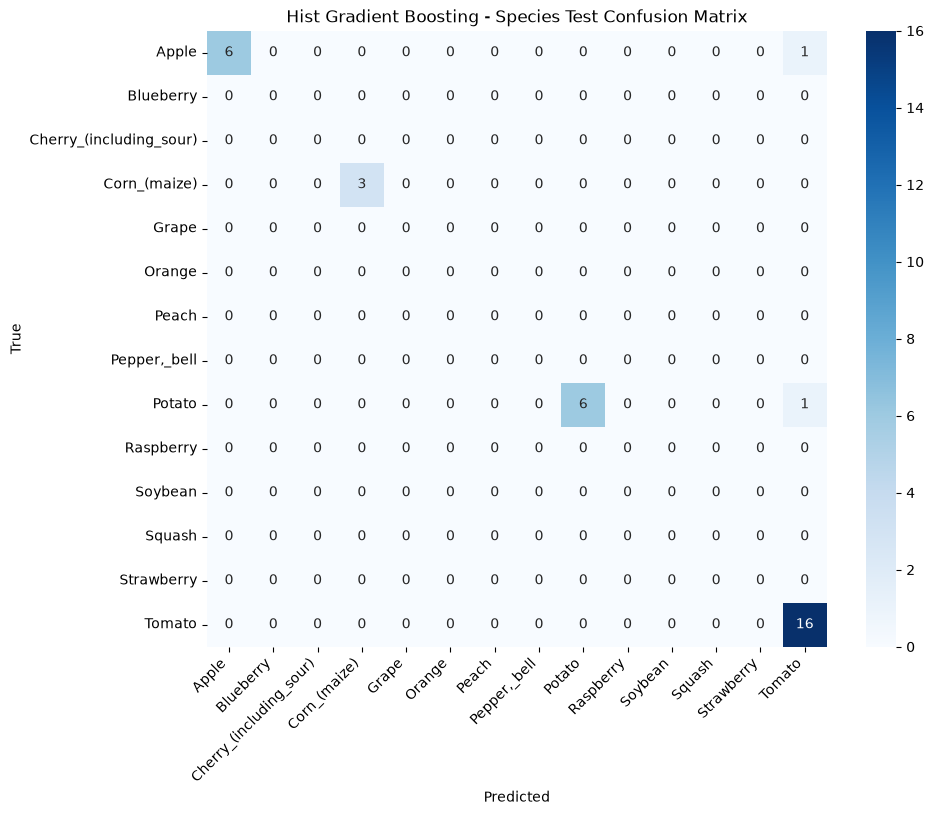

In [62]:
final_preds = best_species_model.predict(X_test_scaled)
print(f"Final test results for {best_species_name}:\n")
print(classification_report(y_test_species, final_preds))

cm = confusion_matrix(y_test_species, final_preds, labels=SPECIES_LIST)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SPECIES_LIST, yticklabels=SPECIES_LIST)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'{best_species_name} - Species Test Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

In [65]:
report = classification_report(y_test_species, final_preds, output_dict=True)
with open(os.path.join(OUTPUT_DIR, 'classical_ml_species_summary.json'), 'w') as f:
    json.dump({
        "best_model": best_species_name,
        "comparison": {n: {"acc": r["acc"], "f1_macro": r["f1"]} for n, r in species_results.items()},
        "test_report": report,
    }, f, indent=2)
print(f"Saved species classification summary to {OUTPUT_DIR}")

Saved species classification summary to outputs
